# 06C - Random Forest Classifier (Executed Ready)
Run this notebook to generate outputs. The structure is optimized for GitHub.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

df = pd.read_csv("../data/datasets/american_bankruptcy.csv")
df["target"] = df["status_label"].map({"alive":0,"failed":1})
display(df.head())
print(df.shape)


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X10,X11,X12,X13,X14,X15,X16,X17,X18,target
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302,0
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888,0
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514,0
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592,0
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467,0


(78682, 22)


## Data Preparation

In [2]:
drop_cols=["status_label","target"]
if "company_name" in df.columns:
    drop_cols.append("company_name")

X=df.drop(columns=drop_cols)
y=df["target"]

num=X.select_dtypes(include="number").columns
cat=X.select_dtypes(exclude="number").columns

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

pre=ColumnTransformer([
("num",SimpleImputer(strategy="median"),num),
("cat",Pipeline([
("imp",SimpleImputer(strategy="most_frequent")),
("enc",OneHotEncoder(handle_unknown="ignore"))
]),cat)
])


## Train Model

In [3]:
model=Pipeline([
("preprocessor",pre),
("classifier",RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
))
])

model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Cross Validation

In [4]:
cv=cross_validate(model,X_train,y_train,cv=3,
                          scoring=["accuracy","precision","recall","f1","roc_auc"])
pd.DataFrame(cv).describe()


,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
count,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
mean,10.650939,0.332758,0.816729,0.191199,0.546216,0.283188,0.800391
std,0.060124,0.004336,0.003321,0.006069,0.037552,0.011503,0.009105
min,10.581525,0.328429,0.814555,0.187547,0.512931,0.274986,0.791353
25%,10.633036,0.330587,0.814817,0.187696,0.525862,0.276614,0.795805
50%,10.684547,0.332744,0.815080,0.187845,0.538793,0.278242,0.800256
75%,10.685646,0.334922,0.817816,0.193025,0.562859,0.287289,0.804909
max,10.686745,0.337101,0.820552,0.198205,0.586925,0.296337,0.809562


## Evaluation

In [5]:
pred=model.predict(X_test)
prob=model.predict_proba(X_test)[:,1]

results=pd.DataFrame({
"Metric":["Accuracy","Precision","Recall","F1","ROC-AUC"],
"Value":[
accuracy_score(y_test,pred),
precision_score(y_test,pred),
recall_score(y_test,pred),
f1_score(y_test,pred),
roc_auc_score(y_test,prob)]
})
display(results)
print(classification_report(y_test,pred))


,Metric,Value
0,Accuracy,0.807333
1,Precision,0.196024
2,Recall,0.613985
3,F1,0.297172
4,ROC-AUC,0.814710


              precision    recall  f1-score   support

           0       0.97      0.82      0.89     14693
           1       0.20      0.61      0.30      1044

    accuracy                           0.81     15737
   macro avg       0.58      0.72      0.59     15737
weighted avg       0.92      0.81      0.85     15737



## Visualizations

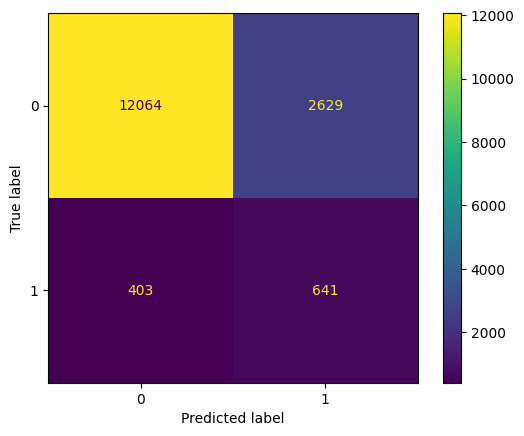

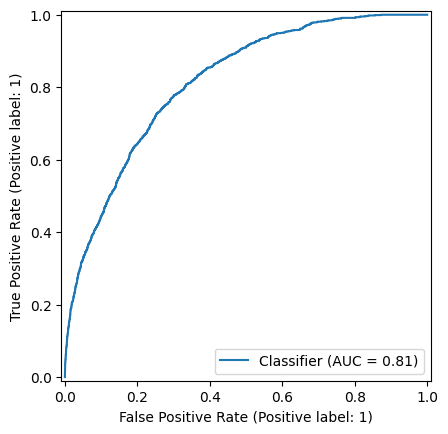

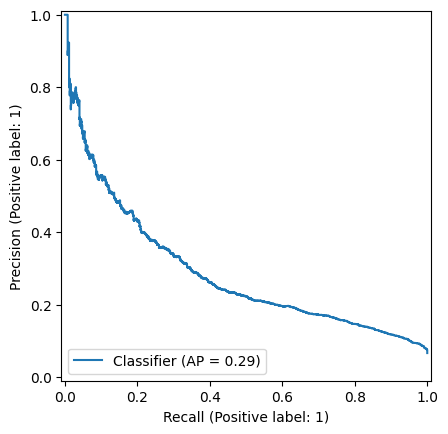

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()

RocCurveDisplay.from_predictions(y_test,prob)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test,prob)
plt.show()


## Feature Importance

In [7]:
rf=model.named_steps["classifier"]
features=list(num)
if len(cat):
    features.extend(
        model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .named_steps["enc"]
        .get_feature_names_out(cat)
    )

importance=(pd.DataFrame({"Feature":features,
                          "Importance":rf.feature_importances_})
            .sort_values("Importance",ascending=False))
display(importance.head(20))


,Feature,Importance
0,year,0.125982
6,X6,0.100218
8,X8,0.091701
11,X11,0.058655
17,X17,0.056982
15,X15,0.056451
3,X3,0.054101
12,X12,0.046472
1,X1,0.046419
7,X7,0.045072


## Save Model

In [8]:
joblib.dump(model,"random_forest_model.joblib")
print("Model saved as random_forest_model.joblib")


Model saved as random_forest_model.joblib
